In [1]:
import os
import sys

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sympy as sy
from IPython.display import display, Math # (formatação matemática)

current_dir = os.path.dirname(os.path.abspath('__file__'))
parent_dir = os.path.dirname(current_dir)
sys.path.insert(0, parent_dir)

from methods.root.bracketing_methods import bissection, false_position
from methods.root.open_methods import fixed_point, newton_raphson, secant
from utils.parser import get_derivative, get_symbolic_function_and_derivative, evaluate_one_variable_vector, evaluate_one_variable


# Métodos para cálculo de raiz de funções

## Intervalares

Os métodos intervalares são técnicas para encontrar raízes de funções contínuas que operam a partir de um intervalo inicial onde há mudança de sinal da função.

__Requisitos__:
- Função contínua no intervalo $[a, b]$
- Raiz única no intervalo $[a, b]$
  - $f'(x) > 0$
  - $f'(x) \neq 0$
  - $f'(x) < 0$
- $f(x_u) \cdot f(x_l) < 0 $

__Métodos__:

- Bisecção
- Falsa posição
  - Convergência lenta para intervalos com curvatura muito acentuada

### Inicialização

In [2]:
func = "x**3 + 5*x**2 - 10"
func_derivative = get_derivative(func)
symbolic_func, symbolic_derivative = get_symbolic_function_and_derivative(func)
xu, xl = 1, 2
xu_plot, xl_plot = -3, 3
num_points = 100
max_iter = 100
tol = 1e-5

display(Math(f"f(x) = {sy.latex(symbolic_func)}"))
display(Math(f"f'(x) = {sy.latex(symbolic_derivative)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Verificar Condições

Unicidade da raiz:
f'(1) = 13
f'(2) = 32

Verificar se há uma raiz única no intervalo [xl, xu]:
f(1) * f(2) = -72.0


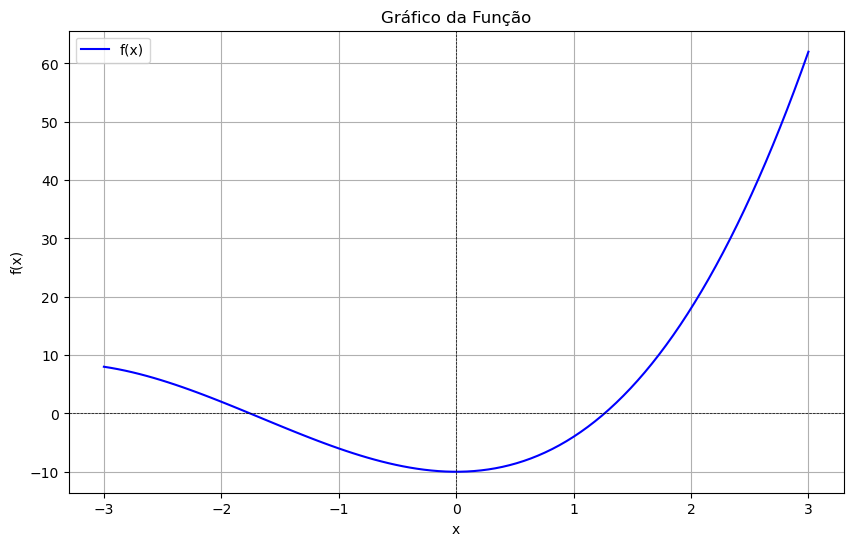

In [3]:
# Unicidade da Raiz
print("Unicidade da raiz:")
print(f"f'({xu}) = {func_derivative(xu)}")
print(f"f'({xl}) = {func_derivative(xl)}\n")

# Verifica se há uma raiz única no intervalo [xl, xu]
print("Verificar se há uma raiz única no intervalo [xl, xu]:")
print(f"f({xu}) * f({xl}) = {evaluate_one_variable(func, xu) * evaluate_one_variable(func, xl)}")

# Plotar o gráfico da função
x = np.linspace(xu_plot, xl_plot, num_points)
y = evaluate_one_variable_vector(func, x)
plt.figure(figsize=(10, 6))

plt.plot(x, y, label='f(x)', color='blue')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title('Gráfico da Função')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.show()

### Calcular raiz

In [4]:
print("\nMétodos intervalares:")
print(f"xl = {xl}, xu = {xu}")

# Executa o método da bisseção
x_bissection = bissection(func, xl, xu, tol=tol, max_iter=max_iter)
x_false_position = false_position(func, xl, xu, tol=tol, max_iter=max_iter)

print(f"Raiz encontrada bissecção: {x_bissection}")
print(f"Raiz encontrada posição falsa: {x_false_position}")


Métodos intervalares:
xl = 2, xu = 1
Raiz encontrada bissecção: 1.2635427713394165
Raiz encontrada posição falsa: 1.263542820954002


### Plotar resultados

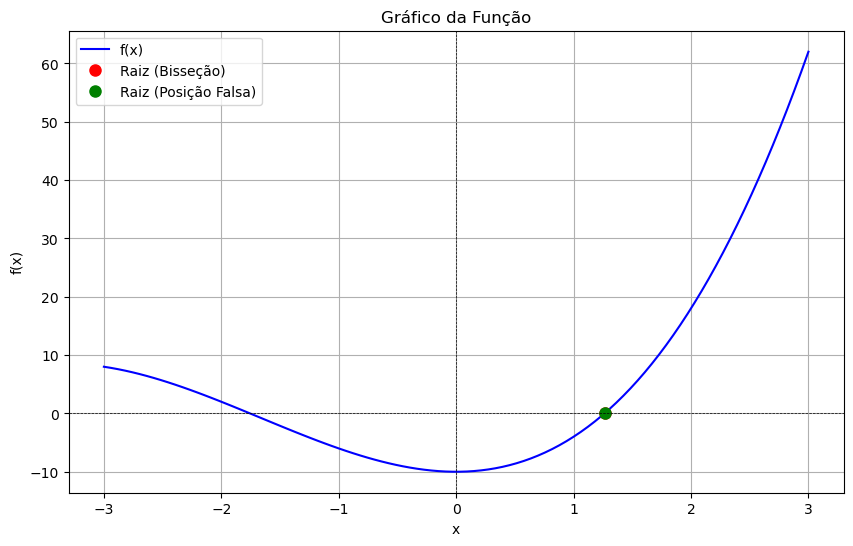

In [5]:
fig = plt.figure(figsize=(10, 6))

plt.plot(x, y, label='f(x)', color='blue')
plt.plot(x_bissection, evaluate_one_variable(func, x_bissection), 'ro', label='Raiz (Bisseção)', markersize=8)
plt.plot(x_false_position, evaluate_one_variable(func, x_false_position), 'go', label='Raiz (Posição Falsa)', markersize=8)
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title('Gráfico da Função')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.show()


## Métodos abertos

Os métodos abertos são técnicas para encontrar raízes de funções que não necessitam de um intervalo inicial com mudança de sinal. Eles se baseiam em aproximações sucessivas a partir de um ou mais pontos iniciais.

__Requisitos__:
  - $f(x)$  é contínua no intervalo $[a, b]$ (todos)
  - Um ou dois pontos iniciais tão próximos quanto possível da solução

__Métodos__:

- Ponto Fixo
  - Depende da curvatura de $g(x)$ e do ponto $x_0$ 
  - $g(x)$ e suas derivadas são contínuas (Ponto Fixo)
  - $|g'(x)| < 1$ o erro diminui a cada iteração e o método converge
  - $|g'(x)| > 1$ o erro aumenta e o método __poderia__ diverger
- Newton Raphson
  - $f(x)$ é duplamente diferenciável em $[x_i, x_u]$
  - $f'(x) \neq 0$
  - O método diverge quando existe um ponto de inflexão $f''(x) = 0$ na vizinhança da raiz
  - O método oscila na vizinhança de um mínimo local e finalmente, diverge. Isso ocorre quando $f'(x) \approx = 0$
  - Instabilidades provocadas por inclinações próximas a zero
- Secante

### Inicialização

In [6]:

func = "x**3 + 5*x**2 - 10"
func_g = "(10/x**2) - 5"
func_derivative = get_derivative(func)
func_g_derivative = get_derivative(func_g)
symbolic_func, symbolic_derivative = get_symbolic_function_and_derivative(func)
symbolic_func_g, symbolic_derivative_func_g = get_symbolic_function_and_derivative(func_g)
xu, xl = 1, 2
xu_plot, xl_plot = -3, 3
num_points = 100
max_iter = 100
tol = 1e-5

display(Math(f"f(x) = {sy.latex(symbolic_func)}"))
display(Math(f"f'(x) = {sy.latex(symbolic_derivative)}"))
display(Math(f"g(x) = {sy.latex(symbolic_func_g)}"))
display(Math(f"g'(x) = {sy.latex(symbolic_derivative_func_g)}"))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

### Verificar Condições


Verificar convergência do método de ponto fixo:
|g'(1)| = 20.0
|g'(2)| = 2.5

Verificar se f'(x) != 0 no intervalo [xl, xu]:
f'(1) = 13
f'(2) = 32

Verificar se há um ponto de inflexão no intervalo [xl, xu]:
f''(1) = 16
f''(2) = 22



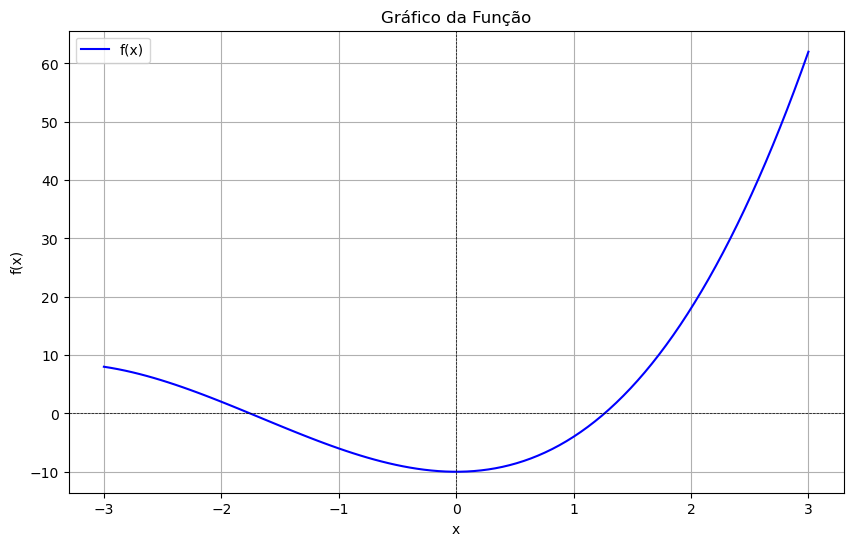

In [7]:
# Verificar convergência método de ponto fixo
print("\nVerificar convergência do método de ponto fixo:")
print(f"|g'({xu})| = {np.abs(func_g_derivative(xu))}")
print(f"|g'({xl})| = {np.abs(func_g_derivative(xl))}\n")

# Verificar se f'(x) != 0 no intervalo [xl, xu]
print("Verificar se f'(x) != 0 no intervalo [xl, xu]:")
print(f"f'({xu}) = {func_derivative(xu)}")
print(f"f'({xl}) = {func_derivative(xl)}\n")

## Verificar se tem um ponto de inflexão no intervalo [xl, xu]
print("Verificar se há um ponto de inflexão no intervalo [xl, xu]:")
print(f"f''({xu}) = {symbolic_derivative.diff().subs(sy.symbols('x'), xu)}")
print(f"f''({xl}) = {symbolic_derivative.diff().subs(sy.symbols('x'), xl)}\n")

# Plotar o gráfico da função
x = np.linspace(xu_plot, xl_plot, num_points)
y = evaluate_one_variable_vector(func, x)
y_g = evaluate_one_variable_vector(func_g, x)
plt.figure(figsize=(10, 6))

plt.plot(x, y, label='f(x)', color='blue')
#plt.plot(x, y_g, label='g(x)', color='orange')
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title('Gráfico da Função')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.show()

### Calcular raiz

In [8]:
print("\nMétodos abertos:")
print(f"xl = {xl}, xu = {xu}")

x_fixed_point = fixed_point(func_g, (xl + xu) / 2, tol=tol, max_iter=max_iter)
print(f"Raiz encontrada ponto fixo: {x_fixed_point}")

x_newton_raphson = newton_raphson(func, func_derivative, (xl + xu) / 2, tol=tol, max_iter=max_iter)
print(f"Raiz encontrada Newton-Raphson: {x_newton_raphson}")

x_secant = secant(func, xl, xu, tol=tol, max_iter=max_iter)
print(f"Raiz encontrada Secante: {x_secant}")



Métodos abertos:
xl = 2, xu = 1
Raiz encontrada ponto fixo: -4.507902869017348
Raiz encontrada Newton-Raphson: 1.2635428474099795
Raiz encontrada Secante: 1.2635428474099772


### Plotar os resultados

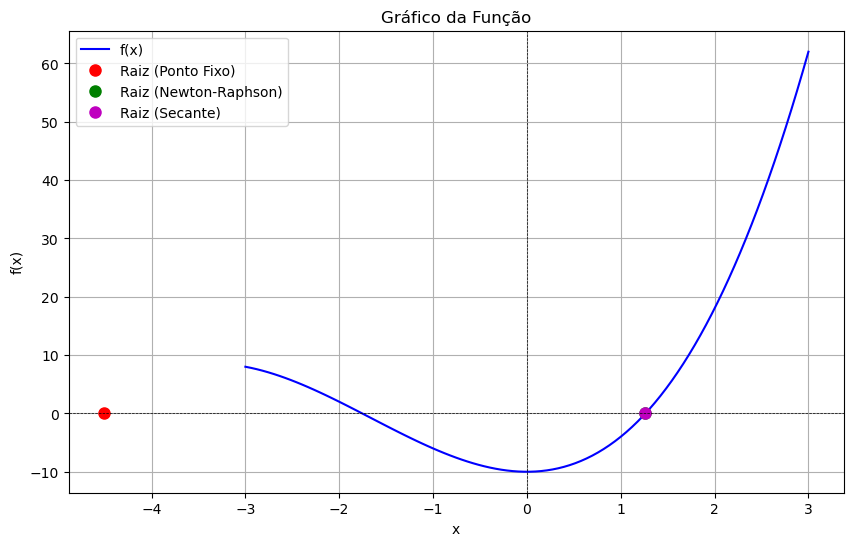

In [9]:
fig = plt.figure(figsize=(10, 6))

plt.plot(x, y, label='f(x)', color='blue')
plt.plot(x_fixed_point, evaluate_one_variable(func, x_fixed_point), 'ro', label='Raiz (Ponto Fixo)', markersize=8)
plt.plot(x_newton_raphson, evaluate_one_variable(func, x_newton_raphson), 'go', label='Raiz (Newton-Raphson)', markersize=8)
plt.plot(x_secant, evaluate_one_variable(func, x_secant), 'mo', label='Raiz (Secante)', markersize=8)
plt.axhline(0, color='black', lw=0.5, ls='--')
plt.axvline(0, color='black', lw=0.5, ls='--')
plt.title('Gráfico da Função')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.grid()
plt.legend()
plt.show()